# DTLZ3 Results

In [1]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 800
NGEN = 600
NOBJ = 4 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz3_segura = partial(benchmarks.dtlz3, obj=NOBJ)
toolbox = build_toolbox(func_dtlz3_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 50
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[1.0, 0.0, 1.6172503769879933e-16, 0.4999999831561365, 0.500000039113503, 0.49999999186111277, 0.49999998980762184, 0.5000005068559917, 0.5000005919815198, 0.5000013206804709, 0.49999998788118855, 0.5000001017308063, 0.4999998795216741]
[0.0, 0.0, 1.0, 0.4999999805536523, 0.5000000394358731, 0.49999999596260797, 0.4999999872703205, 0.5000004650428092, 0.5000005923671984, 0.5000013178562233, 0.4999999878165071, 0.4999999206106311, 0.4999999055135992]
[8.158856385026558e-05, 5.021676495464843e-17, 0.0, 0.49999999763180736, 0.5000000413383836, 0.4999999961917374, 0.4999999882346263, 0.5000005087010494, 0.5050494720536519, 0.5000013158609252, 0.4999999878144214, 0.5000001221757705, 0.49999990155691754]
[1.0, 1.0, 1.0, 0.4999999966615776, 0.5000000386367043, 0.49999999613746243, 0.49999998820291086, 0.5000004922497606, 0.5000005910388676, 0.5000013146412066, 0.4999999859980911, 0.4999999638440178, 0.4999999074736333]
[0.0, 0.0, 4.9377194649133344e-17, 0.49999999727171507, 0.5000000426485687

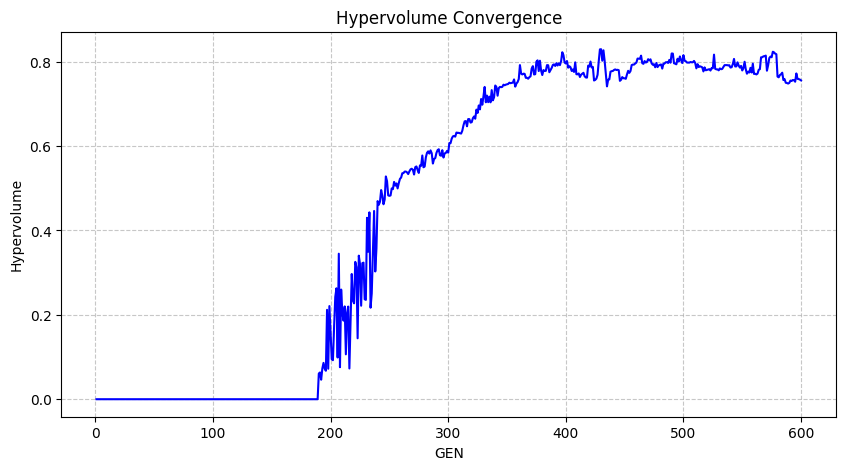

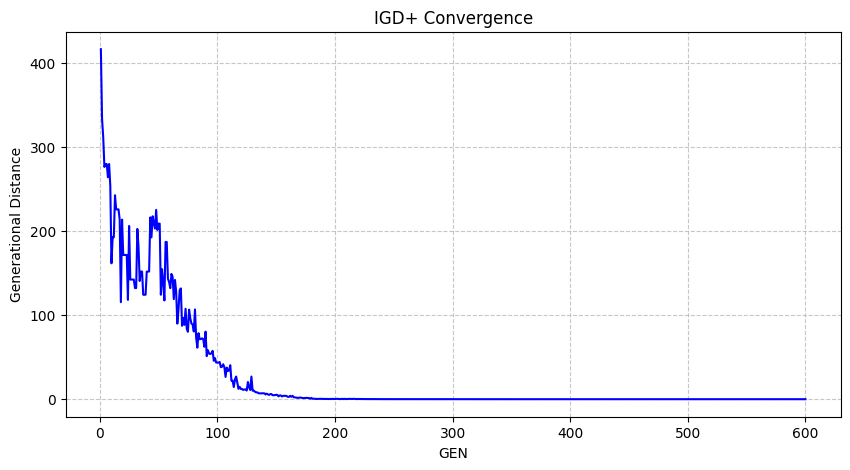

In [2]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()